# Анализ лояльности пользователей Яндекс Афиши

https://github.com/exologyNK/Afisha-loyalty-analysis-project

Цель проекта — изучить поведение пользователей Яндекс Афиши и определить, какие пользователи с большей вероятностью возвращаются на платформу и совершают повторные покупки.

В рамках исследования будут проанализированы данные о заказах, устройствах, типах мероприятий, регионах, городах, выручке и времени между покупками пользователей.

Основной фокус анализа — выявить признаки, связанные с повторными заказами и пользовательской лояльностью.

# Шаг 1. Загрузка данных и их предобработка

In [1]:
# импортирую библиотеки для работы
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import phik

In [2]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk as order_dt,
    created_ts_msk as order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk::date
    - LAG(created_dt_msk::date) OVER (
        PARTITION BY user_id
        ORDER BY created_dt_msk::date
    ) AS days_since_prev,
    event_id,
    event_name_code as event_name,
    event_type_main,
    service_name,
    region_name,
    city_name 
FROM afisha.purchases as p 
join afisha.events as e using (event_id) 
join afisha.city as c using (city_id)
join afisha.regions as r using (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop')
AND e.event_type_main != 'фильм'
ORDER BY user_id;
'''

In [6]:
# выгрузка из sql
df = pd.read_sql_query(query, con=engine) 

In [7]:
# смотрим структуру датасета и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [8]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


# Шаг 2. Предобработка данных

In [9]:
# явные дубликкаты
df.duplicated().sum()

np.int64(0)

In [10]:
# пропуски
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

In [11]:
# статистические показатели
df.describe()

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611,290611,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,2024-09-01 22:36:38.741272576,2024-09-02 13:31:19.397730816,625.584360,2.754311,3.222381,438019.834992
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,2024-09-12 00:00:00,2024-09-12 14:02:10,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.540000,57.000000,148.000000,592325.000000
std,2.497551e+06,NaN,NaN,1227.693064,1.170620,11.350509,147423.078841


In [12]:
# уникальные значения
df[['device_type_canonical', 'currency_code', 'event_type_main']].nunique()

device_type_canonical    2
currency_code            2
event_type_main          7
dtype: int64

In [13]:
# датасэт с курсом рубля к тэнге
tenge_df = pd.read_csv('final_tickets_tenge_df.csv')

In [14]:
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [15]:
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [16]:
tenge_df['data'] = pd.to_datetime(tenge_df['data'])
df['order_dt'] = pd.to_datetime(df['order_dt'])

In [17]:
df = df.merge(
    tenge_df[['data', 'curs']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

In [18]:
df[['currency_code', 'revenue', 'curs']].head()

,currency_code,revenue,curs
0,rub,1521.94,18.6972
1,rub,289.45,18.3419
2,rub,1258.57,19.6475
3,rub,8.49,18.5010
4,rub,1390.41,19.6648


In [19]:
df['revenue_rub'] = df['revenue']

df.loc[df['currency_code'] == 'kzt','revenue_rub'] = df['revenue'] * df['curs'] / 100

In [20]:
df[df['currency_code'] == 'kzt'][[
    'currency_code',
    'revenue',
    'curs',
    'revenue_rub'
]].head()

,currency_code,revenue,curs,revenue_rub
70,kzt,518.10,19.0125,98.503762
89,kzt,347.18,18.9330,65.731589
96,kzt,328.77,18.5991,61.148261
277,kzt,22021.55,19.8928,4380.702898
460,kzt,7397.66,19.9833,1478.296591


In [21]:
df[df['currency_code'] == 'rub'][[
    'currency_code',
    'revenue',
    'revenue_rub'
]].head()

,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


### Промежуточный вывод
Выручка была приведена к единой валюте — российскому рублю. Для заказов, оплаченных в тенге, использованы ежедневные курсы конвертации из файла final_tickets_tenge_df.csv. Результат сохранён в новом столбце revenue_rub. Для заказов, оплаченных в рублях, значения выручки оставлены без изменений.

In [22]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
data                         0
curs                         0
revenue_rub                  0
dtype: int64

Пропуски в days_since_prev обоснованы тк не все пользователи имеют 2-ой заказ, дальнеййшей обработки не требуют

In [23]:
df.duplicated().sum()

np.int64(0)

Явные дубликаты отсутствуют

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [25]:
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()

,revenue_rub,tickets_count,days_since_prev
count,290611.000000,290611.000000,268678.000000
mean,555.571987,2.754311,3.222381
std,875.498172,1.170620,11.350509
min,-90.760000,1.000000,0.000000
25%,113.970000,2.000000,0.000000
50%,351.140000,3.000000,0.000000
75%,802.050000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


In [26]:
df = df.drop(columns=['data', 'curs'])

In [27]:
# кол-во отрицательных revenue
(df['revenue_rub'] < 0).sum()

np.int64(381)

In [28]:
df[df['revenue_rub'] < 0][
    ['order_id', 'currency_code', 'revenue', 'revenue_rub']
].head()

,order_id,currency_code,revenue,revenue_rub
252,1594653,rub,-2.37,-2.37
4538,2360920,rub,-0.23,-0.23
4556,2361094,rub,-0.15,-0.15
8141,166809,rub,-0.62,-0.62
8142,166780,rub,-1.86,-1.86


In [29]:
df['tickets_count'].value_counts().sort_index()

tickets_count
1     41798
2     83807
3     92247
4     54812
5     13476
6      4283
7        62
8        21
9        38
10       19
11       13
12        4
13        7
14        4
15        2
17        6
19        5
27        2
30        2
37        1
47        1
57        1
Name: count, dtype: int64

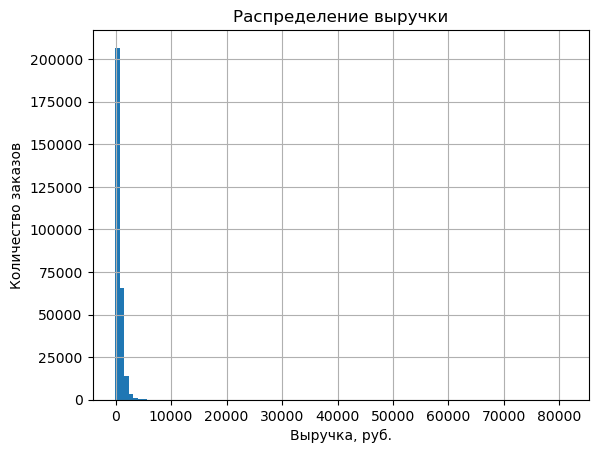

In [30]:
df['revenue_rub'].hist(bins=100)
plt.title('Распределение выручки')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

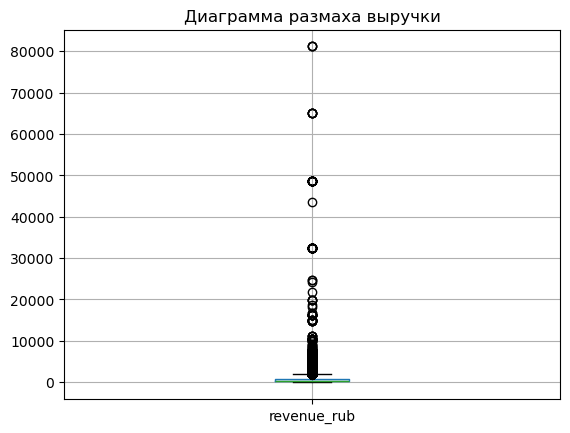

In [31]:
df.boxplot(column='revenue_rub')
plt.title('Диаграмма размаха выручки')
plt.show()

In [32]:
# 99й перцентиль revenue
p99 = df['revenue_rub'].quantile(0.99)
print(p99)

2628.4217390400004


In [33]:
rows_before = len(df)
df = df[df['revenue_rub'] <= p99]

In [34]:
rows_after = len(df)

print('Было строк:', rows_before)
print('Стало строк:', rows_after)
print('Удалено строк:', rows_before - rows_after)
print(
    'Удалено, %:',
    round((rows_before - rows_after) / rows_before * 100, 2)
)

Было строк: 290611
Стало строк: 287786
Удалено строк: 2825
Удалено, %: 0.97


In [35]:
# статистика после фильтрации
df['revenue_rub'].describe()

count    287786.000000
mean        518.029224
std         511.963780
min         -90.760000
25%         111.850000
50%         343.850000
75%         788.660000
max        2628.421739
Name: revenue_rub, dtype: float64

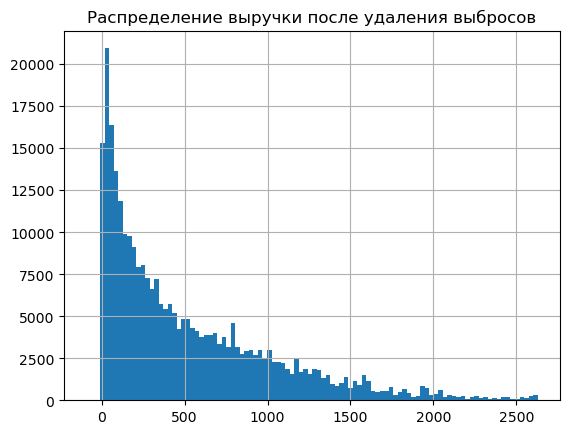

In [36]:
# график после фильтрации
df['revenue_rub'].hist(bins=100)
plt.title('Распределение выручки после удаления выбросов')
plt.show()

### Вывод по шагу 2

На этапе предобработки все значения выручки были приведены к единой валюте - российскому рублю. Для заказов, оплаченных в казахстанских тенге, использовались ежедневные курсы из файла `final_tickets_tenge_df.csv`. Рассчитанные значения сохранены в новом столбце `revenue_rub`.

Проверка данных показала, что пропуски присутствуют только в столбце `days_since_prev`. Такие пропуски ожидаемы, поскольку для первой покупки пользователя отсутствует предыдущий заказ, относительно которого можно рассчитать интервал. Дополнительная обработка этих значений не потребовалась.

Явных дубликатов в датасете не обнаружено.

При анализе выручки были найдены как отрицательные значения, так и очень крупные заказы. Отрицательные значения, вероятно, связаны с возвратами или корректировками и были сохранены, поскольку могут отражать реальные бизнес-процессы.

Чтобы отдельные крупные заказы не оказывали чрезмерного влияния на результаты анализа, данные были ограничены 99-м перцентилем по выручке. Порог составил 2628 рублей. После фильтрации было исключено 2825 записей, что соответствует примерно 0,97% всех наблюдений. Таким образом, основная часть данных была сохранена, а распределение выручки стало более удобным для дальнейшего анализа.



# Шаг 3. Создание профиля пользователя

## Задача 3.1.

In [37]:
df = df.sort_values(['user_id', 'order_ts'])

In [38]:
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    orders_count=('order_id', 'nunique'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

In [39]:
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

In [40]:
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [41]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21854 non-null  object        
 1   first_order_dt       21854 non-null  datetime64[ns]
 2   last_order_dt        21854 non-null  datetime64[ns]
 3   first_device         21854 non-null  object        
 4   first_region         21854 non-null  object        
 5   first_service        21854 non-null  object        
 6   first_event_type     21854 non-null  object        
 7   orders_count         21854 non-null  int64         
 8   avg_revenue_rub      21854 non-null  float64       
 9   avg_tickets_count    21854 non-null  float64       
 10  avg_days_since_prev  13513 non-null  float64       
 11  is_two               21854 non-null  int64         
 12  is_five              21854 non-null  int64         
dtypes: datetime64[ns](2), float64(3

### Вывод по задаче 3.1

Для каждого пользователя был сформирован единый профиль на основе истории его заказов. В результате удалось агрегировать данные по 21 854 пользователям и получить ключевые характеристики поведения: дату первого и последнего заказа, устройство, регион, билетного оператора и тип мероприятия первого заказа, а также показатели активности пользователя.

В профиль были включены количественные метрики: общее число заказов, средняя выручка с заказа, среднее количество билетов в заказе и средний интервал между покупками. Дополнительно сформированы бинарные признаки, отражающие факт совершения пользователем двух и более заказов (`is_two`) и пяти и более заказов (`is_five`).

Полученный датасет объединяет как характеристики первого взаимодействия пользователя с сервисом, так и показатели его дальнейшей активности. Это позволяет использовать профиль для исследования факторов, связанных с повторными покупками и удержанием пользователей на платформе.


## Задача 3.2

In [42]:
users_count = user_profile['user_id'].nunique()
avg_revenue_per_order = df['revenue_rub'].mean()
share_two = user_profile['is_two'].mean()
share_five = user_profile['is_five'].mean()

print('Количество пользователей:', users_count)
print('Средняя выручка с одного заказа:', round(avg_revenue_per_order, 2))
print('Доля пользователей с 2+ заказами:', round(share_two * 100, 2), '%')
print('Доля пользователей с 5+ заказами:', round(share_five * 100, 2), '%')

Количество пользователей: 21854
Средняя выручка с одного заказа: 518.03
Доля пользователей с 2+ заказами: 61.71 %
Доля пользователей с 5+ заказами: 29.01 %


In [43]:
user_profile[['orders_count', 'avg_tickets_count', 'avg_days_since_prev']].describe()

,orders_count,avg_tickets_count,avg_days_since_prev
count,21854.000000,21854.000000,13513.000000
mean,13.168573,2.743129,15.849778
std,121.674800,0.913080,22.315215
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.076923,20.500000
max,10181.000000,11.000000,148.000000


In [44]:
user_profile['orders_count'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1])

0.50        2.00
0.75        5.00
0.90       15.00
0.95       31.35
0.99      152.00
1.00    10181.00
Name: orders_count, dtype: float64

In [45]:
user_profile['avg_tickets_count'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1])

0.50     2.750000
0.75     3.076923
0.90     4.000000
0.95     4.000000
0.99     5.000000
1.00    11.000000
Name: avg_tickets_count, dtype: float64

In [46]:
user_profile.sort_values(
    'orders_count',
    ascending=False
)[['user_id', 'orders_count']].head(20)

,user_id,orders_count
981,0beb8fc0c0a9ce1,10181
2054,18e9aead0a393e7,4351
11073,8187dac4be757a0,4021
5414,3ee7dc2e115847f,3791
10810,7eb4fc207ecc10f,3710
2330,1c2a2133e1df1b4,3503
6776,4ec8f6429431987,3375
14765,ad2dc32364ed948,3249
15502,b54dd0cd81121fc,3138
17634,cdbc02c6ad8087a,3036


In [47]:
p99_orders = user_profile['orders_count'].quantile(0.99)

user_profile_filtered = user_profile[
    user_profile['orders_count'] <= p99_orders
]

In [48]:
rows_before = len(user_profile)

user_profile_filtered = user_profile[
    user_profile['orders_count'] <= p99_orders
]

rows_after = len(user_profile_filtered)

print('Удалено пользователей:', rows_before - rows_after)
print(
    'Удалено, %:',
    round((rows_before - rows_after) / rows_before * 100, 2)
)

Удалено пользователей: 216
Удалено, %: 0.99


In [49]:
user_profile_filtered[
    ['orders_count', 'avg_tickets_count', 'avg_days_since_prev']
].describe()

,orders_count,avg_tickets_count,avg_days_since_prev
count,21638.000000,21638.000000,13297.000000
mean,6.501294,2.743319,16.099794
std,14.324031,0.917486,22.408626
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.333333
50%,2.000000,2.750000,8.352941
75%,5.000000,3.095238,20.800000
max,152.000000,11.000000,148.000000


### Вывод по задаче 3.2 
В выборке представлено 21 854 пользователя. Средняя выручка с одного заказа после предобработки составляет 518,03 руб. Доля пользователей, совершивших 2 и более заказа, равна 61,71%, а доля пользователей с 5 и более заказами — 29,01%.

При анализе профилей были обнаружены аномальные значения в количестве заказов: при медиане 2 заказа максимум достигал 10 181 заказа. Такие значения сильно отличаются от основной массы пользователей, поэтому данные были отфильтрованы по 99-му перцентилю количества заказов. В результате удалено 216 пользователей, или 0,99% выборки.

После фильтрации максимальное количество заказов на пользователя составило 152, среднее — 6,5 заказа, медиана — 2 заказа. Среднее количество билетов в заказе выглядит стабильным: медиана — 2,75, 75-й перцентиль — около 3,1, максимум — 11. Существенных аномалий по среднему количеству билетов не выявлено.

## Вывод по шагу 3

Для каждого пользователя был сформирован профиль, включающий характеристики первого заказа, дату первого и последнего обращения к сервису, количество заказов, среднюю выручку, среднее число билетов и средний интервал между покупками. Также были добавлены признаки `is_two` и `is_five`, которые показывают, совершал ли пользователь 2 и более либо 5 и более заказов.

В выборке оказалось более 21 тысячи пользователей. Большинство пользователей совершают небольшое количество заказов, однако встречались и явно нетипичные значения. Чтобы такие наблюдения не искажали результаты исследования, пользователи с экстремально большим числом заказов были исключены по 99-му перцентилю.

Полученный профиль стал основой для дальнейшего анализа факторов, связанных с возвратом пользователей и их активностью на платформе.


# Шаг 4. Исследовательский анализ данных

## 4.1 Исследование признаков первого заказа

### 4.1.1. Распределение пользователей по сегментам

In [50]:
def segment_distribution(data, column):
    result = (
        data
        .groupby(column)
        .agg(users_count=('user_id', 'nunique'))
        .reset_index()
    )
    
    result['users_share'] = (
        result['users_count'] / result['users_count'].sum() * 100
    ).round(2)
    
    return result.sort_values('users_count', ascending=False)

In [51]:
event_type_dist = segment_distribution(user_profile_filtered, 'first_event_type')
event_type_dist

,first_event_type,users_count,users_share
2,концерты,9560,44.18
1,другое,5426,25.08
5,театр,4239,19.59
4,стендап,1110,5.13
3,спорт,794,3.67
0,выставки,414,1.91
6,ёлки,95,0.44


In [52]:
device_dist = segment_distribution(user_profile_filtered, 'first_device')
device_dist

,first_device,users_count,users_share
1,mobile,17924,82.84
0,desktop,3714,17.16


In [53]:
region_dist = segment_distribution(user_profile_filtered, 'first_region')
region_dist.head(10)

,first_region,users_count,users_share
23,Каменевский регион,7085,32.74
60,Североярская область,3767,17.41
77,Широковская область,1224,5.66
45,Озернинский край,675,3.12
41,Малиновоярский округ,525,2.43
76,Шанырский регион,500,2.31
74,Травяная область,488,2.26
57,Светополянский округ,457,2.11
52,Речиновская область,440,2.03
78,Яблоневская область,411,1.90


In [54]:
service_dist = segment_distribution(user_profile_filtered, 'first_service')
service_dist.head(10)

,first_service,users_count,users_share
3,Билеты без проблем,5186,23.97
22,Мой билет,2969,13.72
19,Лови билет!,2809,12.98
4,Билеты в руки,2559,11.83
23,Облачко,2177,10.06
7,Весь в билетах,1285,5.94
20,Лучшие билеты,1184,5.47
24,Прачечная,583,2.69
17,Край билетов,454,2.10
12,Дом культуры,356,1.65


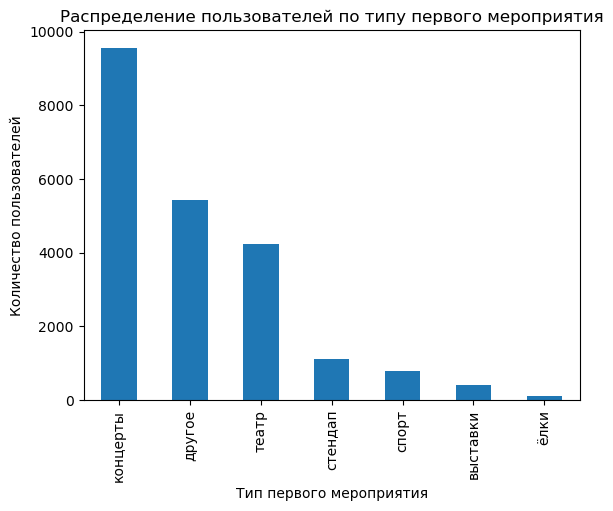

In [55]:
event_type_dist.plot(
    x='first_event_type',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Количество пользователей')
plt.show()

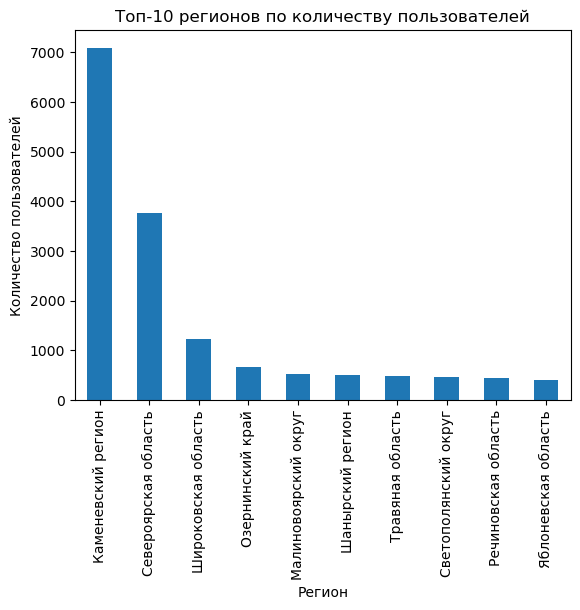

In [56]:
region_dist.head(10).plot(
    x='first_region',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Топ-10 регионов по количеству пользователей')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.show()

### Вывод по 4.1.1

Распределение пользователей по сегментам оказалось неравномерным.

Чаще всего знакомство с сервисом начинается с покупки билетов на концерты - через этот тип мероприятий пришла почти половина пользователей. На втором месте находятся мероприятия категории «другое», затем театр. Остальные категории заметно уступают им по численности.

Большинство пользователей оформляют первый заказ с мобильного устройства. Доля мобильных устройств превышает 80%, поэтому именно мобильный канал можно считать основным способом взаимодействия с платформой.

По регионам и билетным операторам также выделяются несколько крупных сегментов, которые формируют значительную часть аудитории. При этом распределение между операторами выглядит более сбалансированным, чем распределение между регионами.


### 4.1.2 Анализ возвратов по сегментам

In [57]:
event_return = (
    user_profile_filtered
    .groupby('first_event_type')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

event_return['return_rate'] = (
    event_return['return_rate'] * 100
).round(2)

event_return.sort_values(
    'return_rate',
    ascending=False
)

,first_event_type,users_count,return_rate
0,выставки,414,64.01
5,театр,4239,63.39
2,концерты,9560,61.83
4,стендап,1110,60.90
1,другое,5426,59.62
3,спорт,794,55.79
6,ёлки,95,55.79


In [58]:
device_return = (
    user_profile_filtered
    .groupby('first_device')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

device_return['return_rate'] = (
    device_return['return_rate'] * 100
).round(2)

device_return

,first_device,users_count,return_rate
0,desktop,3714,63.81
1,mobile,17924,60.81


In [59]:
region_return = (
    user_profile_filtered
    .groupby('first_region')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

region_return['return_rate'] = (
    region_return['return_rate'] * 100
).round(2)

region_return.sort_values(
    'users_count',
    ascending=False
).head(10)

,first_region,users_count,return_rate
23,Каменевский регион,7085,62.40
60,Североярская область,3767,63.82
77,Широковская область,1224,64.54
45,Озернинский край,675,55.26
41,Малиновоярский округ,525,56.00
76,Шанырский регион,500,67.20
74,Травяная область,488,61.48
57,Светополянский округ,457,65.65
52,Речиновская область,440,63.41
78,Яблоневская область,411,59.37


In [60]:
service_return = (
    user_profile_filtered
    .groupby('first_service')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

service_return['return_rate'] = (
    service_return['return_rate'] * 100
).round(2)

service_return.sort_values(
    'users_count',
    ascending=False
).head(10)

,first_service,users_count,return_rate
3,Билеты без проблем,5186,60.41
22,Мой билет,2969,60.86
19,Лови билет!,2809,60.91
4,Билеты в руки,2559,62.72
23,Облачко,2177,61.28
7,Весь в билетах,1285,62.88
20,Лучшие билеты,1184,61.23
24,Прачечная,583,62.61
17,Край билетов,454,65.20
12,Дом культуры,356,64.61


### Вывод по задаче 4.1.2. Анализ возвратов по сегментам

Доля пользователей, совершивших повторную покупку, отличается в зависимости от характеристик первого заказа.

Среди типов мероприятий самые высокие показатели возврата наблюдаются у выставок (64,01%) и театров (63,39%). Немного ниже доля повторных покупок у пользователей, которые впервые приобрели билеты на концерты (61,83%). При этом концерты являются самым массовым сегментом и привлекают около 44% всех пользователей платформы. Это позволяет рассматривать их как одну из наиболее важных точек входа с точки зрения дальнейшего удержания аудитории.

Наименьшая доля повторных заказов зафиксирована у пользователей, которые начали пользоваться сервисом через спортивные мероприятия и ёлки. В обоих сегментах показатель возврата составил 55,79%.

По устройству первого заказа различия оказались незначительными. Среди пользователей, оформивших первый заказ с компьютера, повторную покупку совершили 63,81%, тогда как среди мобильных пользователей этот показатель составил 60,81%. Разница находится на уровне 3 процентных пунктов, поэтому устройство первого заказа вряд ли оказывает существенное влияние на возврат клиентов.

Более заметные различия наблюдаются между регионами. Среди крупнейших регионов доля повторных заказов изменяется от 55,26% до 67,20%. Самый высокий показатель отмечен в Шанырском регионе (67,20%), а самый низкий - в Озернинском крае (55,26%). Разрыв почти в 12 процентных пунктов может указывать на влияние региональных особенностей на поведение пользователей.

У билетных операторов разброс показателей оказался значительно меньше. Среди крупнейших операторов доля возврата находится в диапазоне от 60,41% до 65,20%. Лучший результат показал оператор «Край билетов» (65,20%), а самый низкий - «Билеты без проблем» (60,41%). Разница менее 5 процентных пунктов говорит о том, что влияние билетного оператора на вероятность повторной покупки выражено слабее, чем влияние типа мероприятия или региона.

В целом наиболее заметные различия в возвратах наблюдаются между типами мероприятий и регионами. Именно эти признаки выглядят наиболее перспективными для дальнейшего анализа факторов удержания пользователей.


### 4.1.3 Проверка продуктовых гипотез

#### Гипотеза 1

Пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие первый заказ на концерты.

Смотрим результаты:

Тип мероприятия	Return Rate
Концерты	61.83%
Спорт	55.79%

Получается:

55.79% < 61.83%
Вывод

Гипотеза не подтвердилась.

Пользователи, впервые посетившие концерты, возвращаются чаще пользователей, чей первый заказ был связан со спортивными мероприятиями. Доля пользователей с повторными заказами составляет 61,83% для концертов против 55,79% для спорта. Разница составляет около 6 процентных пунктов в пользу концертов.

#### Гипотеза 2

В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Для проверки нужно сравнить:

Самые крупные регионы
Регион	Пользователей	Return Rate
Каменевский регион	7085	62.40%
Североярская область	3767	63.82%
Широковская область	1224	64.54%
Менее крупные регионы из топ-10
Регион	Пользователей	Return Rate
Шанырский регион	500	67.20%
Светополянский округ	457	65.65%
Речиновская область	440	63.41%

Видим, что некоторые менее массовые регионы показывают более высокую долю возвратов, чем крупнейшие регионы.

Например:

Шанырский регион:
500 пользователей
67.20% возвратов

Каменевский регион:
7085 пользователей
62.40% возвратов
Вывод

Гипотеза не подтверждается.

По данным нельзя сделать вывод о том, что более массовые регионы характеризуются более высокой долей повторных заказов. Напротив, некоторые регионы с относительно небольшим количеством пользователей демонстрируют более высокий уровень возврата, чем крупнейшие регионы выборки. Следовательно, прямой зависимости между размером региона по количеству пользователей и вероятностью повторного заказа не наблюдается.

### Вывод по разделу 4.1

Характеристики первого заказа действительно связаны с вероятностью возврата пользователя, однако степень влияния различается.

Наиболее заметные различия наблюдаются между типами мероприятий и регионами. Пользователи, которые начали пользоваться сервисом через театр, концерты или выставки, возвращаются чаще других. При этом обе проверенные гипотезы не подтвердились: пользователи спортивных мероприятий возвращаются реже пользователей концертов, а высокая активность региона не гарантирует более высокий уровень повторных покупок.

Устройство первого заказа и билетный оператор также влияют на возвраты, но различия между сегментами здесь заметно меньше.


## 4.2 Исследование выручки и состава заказа

### 4.2.1 Средняя выручка и повторные покупки

In [61]:
one_order = user_profile_filtered[
    user_profile_filtered['orders_count'] == 1
]

repeat_users = user_profile_filtered[
    user_profile_filtered['orders_count'] >= 2
]

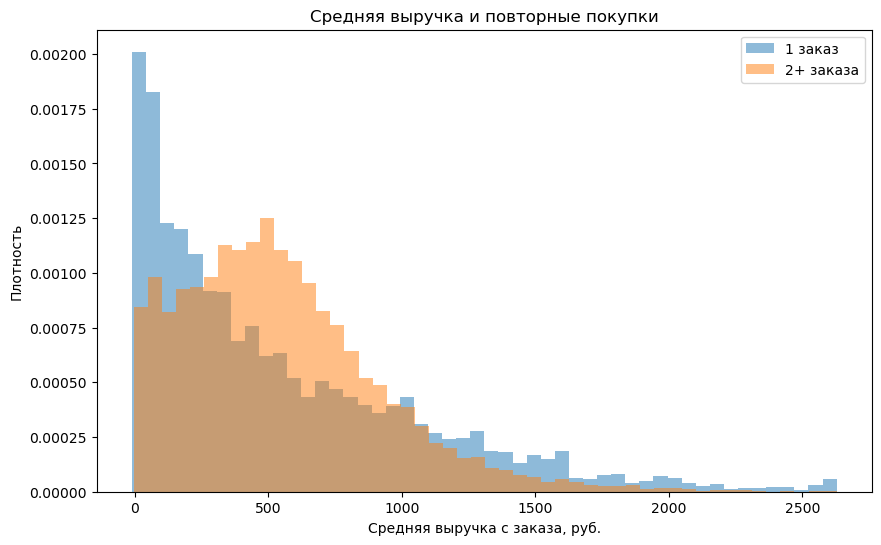

In [62]:
plt.figure(figsize=(10, 6))

plt.hist(
    one_order['avg_revenue_rub'],
    bins=50,
    alpha=0.5,
    density=True,
    label='1 заказ'
)

plt.hist(
    repeat_users['avg_revenue_rub'],
    bins=50,
    alpha=0.5,
    density=True,
    label='2+ заказа'
)

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Средняя выручка и повторные покупки')
plt.legend()

plt.show()

In [63]:
one_order['avg_revenue_rub'].describe()

count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [64]:
repeat_users['avg_revenue_rub'].describe()

count    13270.000000
mean       544.337170
std        369.354468
min         -5.385000
25%        270.814375
50%        495.772429
75%        745.165500
max       2628.421739
Name: avg_revenue_rub, dtype: float64

### Вывод по задаче 4.2.1

Распределения пользователей с одним заказом и пользователей с повторными покупками заметно различаются.

Пользователи, совершившие только один заказ, чаще концентрируются в области небольшой средней выручки — примерно до 200–300 рублей. Для этой группы характерен высокий пик в зоне низких значений.

У пользователей, совершивших 2 и более заказа, распределение смещено вправо. Наибольшая концентрация наблюдается в диапазоне примерно 300–700 рублей, а медианная выручка заметно выше (496 руб. против 378 руб.).

При этом средние значения выручки в двух группах практически совпадают (545 руб. и 544 руб.), поэтому для анализа более показательными оказываются медиана и форма распределения.

Таким образом, данные позволяют предположить, что пользователи с более высокой средней стоимостью заказа имеют более высокую вероятность совершения повторных покупок. Однако связь нельзя назвать очень сильной, поскольку распределения групп существенно пересекаются.

### 4.2.2 Средняя выручка и количество заказов

In [65]:
users_2_4 = user_profile_filtered[
    (user_profile_filtered['orders_count'] >= 2)
    &
    (user_profile_filtered['orders_count'] <= 4)
]

users_5_plus = user_profile_filtered[
    user_profile_filtered['orders_count'] >= 5
]

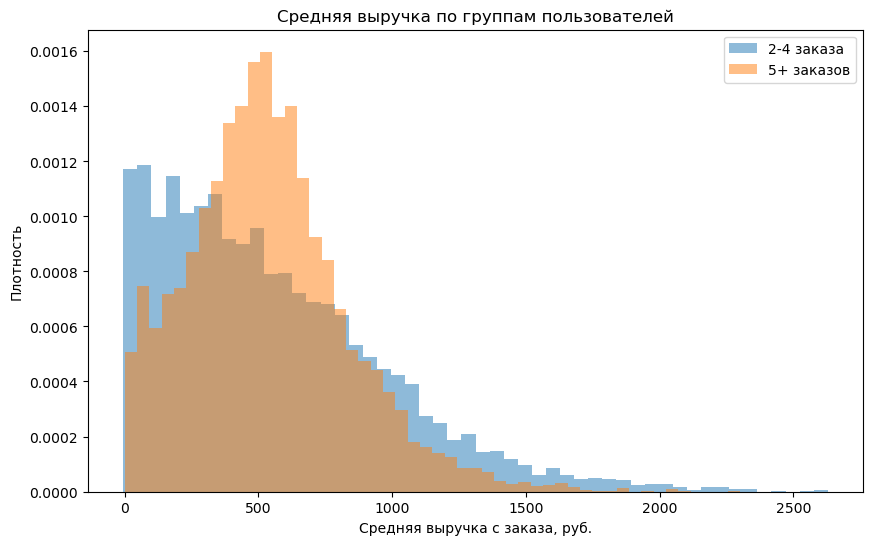

In [66]:
plt.figure(figsize=(10, 6))

plt.hist(
    users_2_4['avg_revenue_rub'],
    bins=50,
    alpha=0.5,
    density=True,
    label='2-4 заказа'
)

plt.hist(
    users_5_plus['avg_revenue_rub'],
    bins=50,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Средняя выручка по группам пользователей')
plt.legend()

plt.show()

In [67]:
users_2_4['avg_revenue_rub'].describe()

count    7147.000000
mean      551.572386
std       420.197691
min        -5.385000
25%       218.428750
50%       471.266667
75%       798.550000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

In [68]:
users_5_plus['avg_revenue_rub'].describe()

count    6123.000000
mean      535.891950
std       299.089582
min         0.000000
25%       330.456122
50%       512.650613
75%       700.809038
max      2299.869022
Name: avg_revenue_rub, dtype: float64

### Вывод по задаче 4.2.2

Сравнение пользователей с 2–4 заказами и 5+ заказами показало, что между группами существуют различия в распределении средней выручки с заказа.

Метрика	2–4 заказа	5+ заказов
Среднее	551,57 руб.	535,89 руб.
Медиана	471,27 руб.	512,65 руб.
25%	218,43 руб.	330,46 руб.
75%	798,55 руб.	700,81 руб.

По графику видно, что распределение пользователей с 5 и более заказами более сконцентрировано в диапазоне 300–700 рублей, а пик распределения расположен около 500–600 рублей.

У пользователей с 2–4 заказами распределение более растянуто:

чаще встречаются очень дешёвые заказы;
наблюдается более длинный правый хвост;
выше разброс значений (стандартное отклонение 420 руб. против 299 руб.).

Интересно, что средняя выручка у группы 2–4 заказа немного выше, однако это объясняется наличием дорогих заказов. Более показательна медиана: у пользователей с 5+ заказами она выше (513 руб. против 471 руб.).

Ответ на вопрос задания

Можно сделать вывод, что наиболее лояльные пользователи (5+ заказов) в среднем совершают несколько более дорогие заказы и характеризуются более стабильным уровнем трат. При этом различия между группами нельзя назвать радикальными, поскольку распределения существенно пересекаются.

### 4.2.3 Количество билетов и вероятность возврата

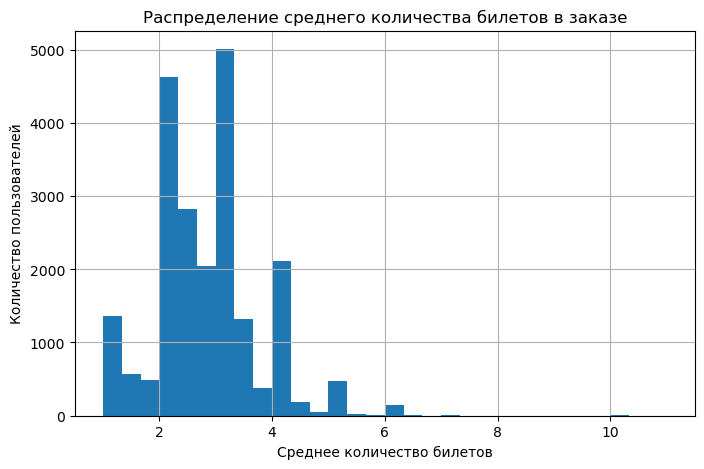

In [69]:
plt.figure(figsize=(8, 5))

user_profile_filtered['avg_tickets_count'].hist(
    bins=30
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')

plt.show()

In [70]:
user_profile_filtered['avg_tickets_count'].describe()

count    21638.000000
mean         2.743319
std          0.917486
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets_count, dtype: float64

In [71]:
user_profile_filtered = user_profile_filtered.copy()

user_profile_filtered['tickets_segment'] = pd.cut(
    user_profile_filtered['avg_tickets_count'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=[
        '1-2 билета',
        '2-3 билета',
        '3-5 билетов',
        '5+ билетов'
    ],
    include_lowest=True
)

In [72]:
user_profile_filtered['tickets_segment'].value_counts()

tickets_segment
2-3 билета     9935
1-2 билета     6160
3-5 билетов    5349
5+ билетов      194
Name: count, dtype: int64

In [73]:
tickets_analysis = (
    user_profile_filtered
    .groupby('tickets_segment')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_analysis['return_rate'] = (
    tickets_analysis['return_rate'] * 100
).round(2)

tickets_analysis

C:\Users\samel\AppData\Local\Temp\ipykernel_19140\1432474128.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tickets_segment')


,tickets_segment,users_count,return_rate
0,1-2 билета,6160,40.15
1,2-3 билета,9935,74.28
2,3-5 билетов,5349,62.70
3,5+ билетов,194,32.47


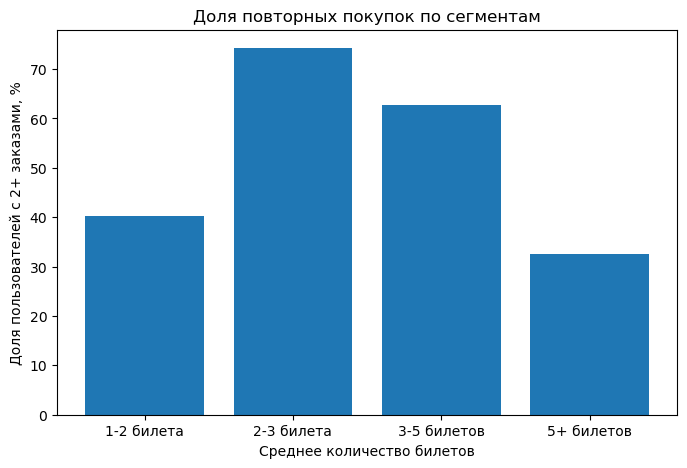

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(
    tickets_analysis['tickets_segment'],
    tickets_analysis['return_rate']
)

plt.title('Доля повторных покупок по сегментам')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля пользователей с 2+ заказами, %')

plt.show()

### Вывод по разделу 4.2
Среднее количество билетов в заказе связано с вероятностью повторной покупки. Наиболее лояльными являются пользователи, приобретающие в среднем 2–3 билета, а пользователи с очень маленькими и очень большими заказами возвращаются заметно реже. Следовательно, количество билетов можно рассматривать как потенциально полезный признак для прогнозирования возврата пользователей.

## 4.3 Исследование временных характеристик

### 4.3.1 День недели первого заказа

In [75]:
user_profile_filtered['first_order_weekday'] = (
    user_profile_filtered['first_order_dt'].dt.day_name()
)
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

In [76]:
weekday_analysis = (
    user_profile_filtered
    .groupby('first_order_weekday')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_analysis['return_rate'] = (
    weekday_analysis['return_rate'] * 100
).round(2)

weekday_analysis

,first_order_weekday,users_count,return_rate
0,Monday,2930,63.04
1,Tuesday,3176,61.90
2,Wednesday,3057,62.19
3,Thursday,3113,59.43
4,Friday,3259,59.83
5,Saturday,3326,62.81
6,Sunday,2777,60.03


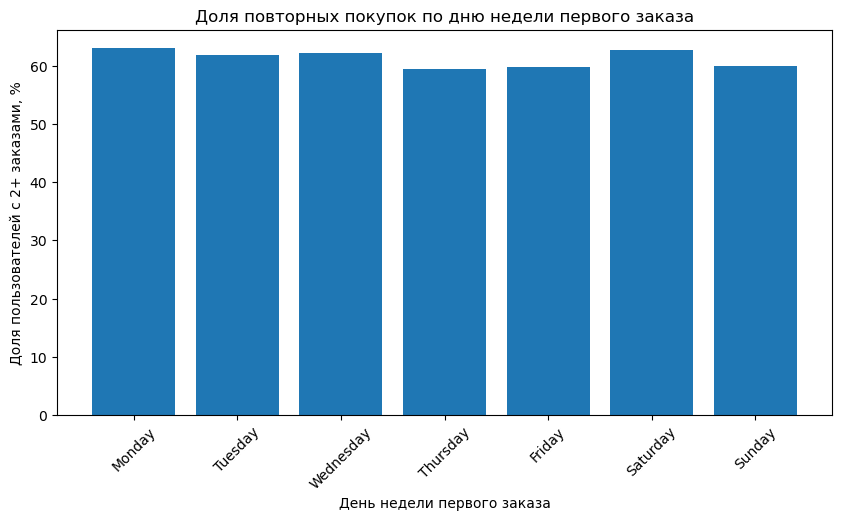

In [77]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_analysis['first_order_weekday'],
    weekday_analysis['return_rate']
)

plt.title('Доля повторных покупок по дню недели первого заказа')
plt.xlabel('День недели первого заказа')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xticks(rotation=45)

plt.show()

### Вывод по задаче 4.3.1

Распределение пользователей по дням недели первого заказа является достаточно равномерным: количество пользователей по каждому дню находится в диапазоне от 2777 до 3326 человек.

Доля пользователей, совершивших повторные заказы, также отличается незначительно:

День недели	Доля возврата
Monday	63,04%
Tuesday	61,90%
Wednesday	62,19%
Thursday	59,43%
Friday	59,83%
Saturday	62,81%
Sunday	60,03%

Максимальное значение наблюдается в понедельник (63,04%), минимальное — в четверг (59,43%).

Разница между лучшим и худшим днём составляет всего около 3,6 процентных пункта.

### Ответ на вопрос задания

День недели первой покупки не оказывает существенного влияния на вероятность возврата пользователя. Независимо от дня недели доля пользователей с повторными заказами остаётся близкой к 60–63%. Следовательно, данный признак вряд ли является сильным фактором удержания клиентов.

### 4.3.2 Интервал между покупками

In [78]:
users_2_4 = user_profile_filtered[
    (user_profile_filtered['orders_count'] >= 2)
    & (user_profile_filtered['orders_count'] <= 4)
]

users_5_plus = user_profile_filtered[
    user_profile_filtered['orders_count'] >= 5
]

In [79]:
users_2_4['avg_days_since_prev'].describe()

count    7147.000000
mean       21.328448
std        28.498259
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_since_prev, dtype: float64

In [80]:
users_5_plus['avg_days_since_prev'].describe()

count    6123.000000
mean        9.898505
std         7.803814
min         0.000000
25%         3.875000
50%         8.125000
75%        14.118056
max        37.500000
Name: avg_days_since_prev, dtype: float64

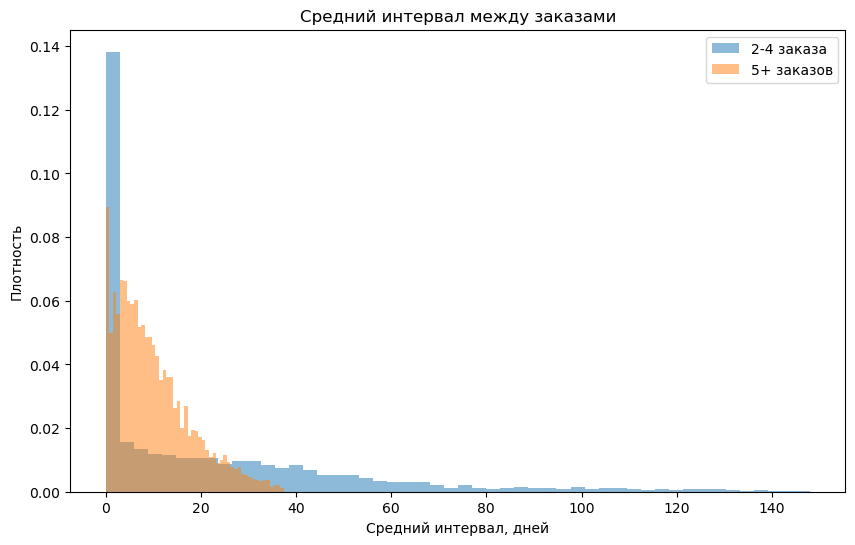

In [81]:
plt.figure(figsize=(10, 6))

plt.hist(
    users_2_4['avg_days_since_prev'].dropna(),
    bins=50,
    alpha=0.5,
    density=True,
    label='2-4 заказа'
)

plt.hist(
    users_5_plus['avg_days_since_prev'].dropna(),
    bins=50,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title('Средний интервал между заказами')
plt.xlabel('Средний интервал, дней')
plt.ylabel('Плотность')
plt.legend()

plt.show()

### Вывод по задаче 4.3.2

Анализ показал заметную связь между средним интервалом между покупками и количеством заказов пользователя.

Сравнение групп
Метрика	2–4 заказа	5+ заказов
Средний интервал	21,32 дня	9,90 дня
Медиана	9 дней	8,13 дня
75% пользователей	до 34 дней	до 14 дней
Максимум	148 дней	37,5 дня
Что видно на графике

Гистограмма показывает существенное различие распределений:

пользователи с 5 и более заказами совершают покупки значительно чаще;
распределение для группы 5+ заказов сосредоточено в диапазоне примерно 0-15 дней;
у пользователей с 2-4 заказами наблюдается гораздо более длинный хвост, достигающий 148 дней;
среди пользователей с большим количеством заказов практически отсутствуют длительные интервалы между покупками.

### Ответ на вопрос задания

Средний интервал между заказами оказывает заметное влияние на удержание пользователей.

Пользователи, которые совершают покупки чаще и имеют небольшие промежутки между заказами, значительно чаще становятся постоянными клиентами сервиса. Для пользователей с 5 и более заказами средний интервал между покупками составляет около 10 дней, тогда как для пользователей с 2–4 заказами - более 21 дня.

Таким образом, сокращение времени между покупками связано с более высокой лояльностью пользователей и может рассматриваться как один из наиболее сильных признаков удержания.

### Вывод по разделу 4.3

Можно написать отдельный общий вывод:

Анализ временных характеристик показал, что день недели первого заказа практически не влияет на вероятность возврата пользователя: доля повторных покупок для всех дней недели находится в диапазоне 59–63%.

В то же время существенное влияние оказывает средний интервал между заказами. Пользователи с большим количеством покупок совершают новые заказы значительно быстрее. Для пользователей с 5 и более заказами средний интервал между покупками примерно в два раза меньше, чем для пользователей с 2–4 заказами. Это позволяет рассматривать частоту покупок как важный индикатор лояльности пользователя.

## 4.4 Корреляционный анализ

### 4.4.1 Анализ Phi_k

In [82]:
# разделение на сегменты
user_profile_filtered = user_profile_filtered.copy()

user_profile_filtered['orders_segment'] = pd.cut(
    user_profile_filtered['orders_count'],
    bins=[0, 1, 4, float('inf')],
    labels=[
        '1 заказ',
        '2-4 заказа',
        '5+ заказов'
    ]
)

In [83]:
user_profile_filtered['orders_segment'].value_counts()

orders_segment
1 заказ       8368
2-4 заказа    7147
5+ заказов    6123
Name: count, dtype: int64

In [84]:
corr_data = user_profile_filtered[
    [
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev',
        'orders_segment'
    ]
]

In [85]:
phik_matrix = corr_data.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev'
    ]
)

phik_matrix

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,orders_segment
first_device,1.000000,0.116370,0.083156,0.061771,0.076388,0.055562,0.016752,0.017110
first_region,0.116370,1.000000,0.696538,0.509207,0.363157,0.163874,0.081426,0.123473
first_service,0.083156,0.696538,1.000000,0.587561,0.378845,0.065908,0.056472,0.081308
first_event_type,0.061771,0.509207,0.587561,1.000000,0.329006,0.095617,0.050183,0.040322
avg_revenue_rub,0.076388,0.363157,0.378845,0.329006,1.000000,0.458801,0.095704,0.326091
avg_tickets_count,0.055562,0.163874,0.065908,0.095617,0.458801,1.000000,0.098930,0.383366
avg_days_since_prev,0.016752,0.081426,0.056472,0.050183,0.095704,0.098930,1.000000,0.391607
orders_segment,0.017110,0.123473,0.081308,0.040322,0.326091,0.383366,0.391607,1.000000


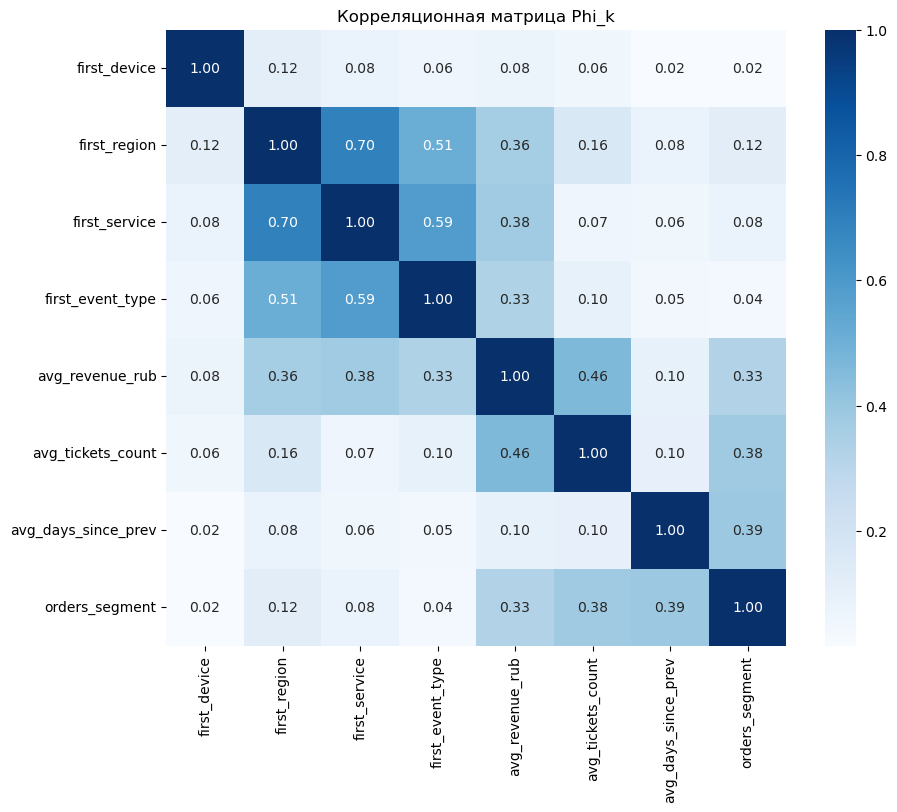

In [86]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phik_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Корреляционная матрица Phi_k')

plt.show()

In [87]:
phik_matrix['orders_segment'].sort_values(
    ascending=False
)

orders_segment         1.000000
avg_days_since_prev    0.391607
avg_tickets_count      0.383366
avg_revenue_rub        0.326091
first_region           0.123473
first_service          0.081308
first_event_type       0.040322
first_device           0.017110
Name: orders_segment, dtype: float64

### Вывод по разделу 4.4

Для оценки связи между характеристиками пользователей и количеством заказов был рассчитан коэффициент корреляции Phi_k, который позволяет анализировать одновременно числовые и категориальные признаки.

Наиболее сильную связь с количеством заказов (orders_segment) показали следующие признаки:

Признак	Phi_k
Средний интервал между заказами (avg_days_since_prev)	0,39
Среднее количество билетов (avg_tickets_count)	0,38
Средняя выручка с заказа (avg_revenue_rub)	0,33
Регион первого заказа (first_region)	0,12
Билетный оператор (first_service)	0,08
Тип первого мероприятия (first_event_type)	0,04
Устройство первого заказа (first_device)	0,02
Основные результаты

Наиболее заметная связь наблюдается между количеством заказов и средним интервалом между покупками. Это подтверждает результаты предыдущего анализа: пользователи, совершающие покупки чаще и с меньшими промежутками времени, обычно оказываются более лояльными и делают больше заказов.

Также относительно сильную связь демонстрируют:

среднее количество билетов в заказе;
средняя выручка с заказа.

Это означает, что характеристики поведения пользователя после первого заказа оказываются более информативными для прогнозирования количества покупок, чем параметры самого первого заказа.

При этом признаки первого заказа показывают значительно более слабую связь с количеством покупок:

устройство практически не влияет на дальнейшую активность пользователя;
тип первого мероприятия влияет слабо;
регион и билетный оператор оказывают некоторое влияние, однако оно заметно уступает поведенческим метрикам.

### Ответ на вопрос задания

Наиболее связанными с количеством заказов оказались:

Средний интервал между заказами (avg_days_since_prev) — Phi_k = 0,39;
Среднее количество билетов в заказе (avg_tickets_count) — Phi_k = 0,38;
Средняя выручка с заказа (avg_revenue_rub) — Phi_k = 0,33.

Таким образом, наибольшую ценность для прогнозирования количества покупок представляют именно поведенческие характеристики пользователя, тогда как параметры первого заказа обладают значительно меньшей объясняющей способностью.

# Шаг 5. Общие выводы и рекомендации

# Общие выводы и рекомендации

В рамках проекта был проведён анализ поведения пользователей Яндекс Афиши с целью выявления факторов, связанных с повторными покупками и удержанием клиентов.

## Подготовка данных

Для анализа были выгружены данные о заказах пользователей и характеристиках мероприятий. В исследование вошли только заказы, совершённые с мобильных и десктопных устройств. Заказы на фильмы были исключены из анализа из-за недостаточного объёма данных.

Выручка была приведена к единой валюте — российскому рублю. Для заказов, оплаченных в казахстанских тенге, использовались исторические курсы за 2024 год. Полученное значение сохранено в поле `revenue_rub`.

В данных отсутствовали пропуски, за исключением поля `days_since_prev`, где пропуски соответствовали пользователям с единственным заказом. Также были выявлены выбросы по выручке и количеству заказов. Для повышения качества анализа данные были отфильтрованы по 99-му перцентилю выручки и количества заказов. В результате было удалено менее 1% пользователей.

## Основные результаты анализа

После подготовки данных в исследовании осталось 21 638 пользователей.

Доля пользователей, совершивших повторные покупки, оказалась достаточно высокой:

* 61,7% пользователей совершили 2 и более заказа;
* 29,0% пользователей совершили 5 и более заказов.

Наиболее популярным типом первого мероприятия являются концерты — через них на платформу пришли 44% пользователей. Основным устройством первого заказа являются мобильные устройства, на которые приходится около 83% пользователей.

### Факторы, связанные с повторными покупками

Анализ показал, что тип первого мероприятия оказывает некоторое влияние на вероятность возврата пользователя. Наиболее высокий уровень возврата наблюдается у пользователей, впервые посетивших выставки и театральные мероприятия. При этом гипотеза о том, что пользователи спортивных мероприятий возвращаются чаще пользователей концертов, не подтвердилась.

Влияние дня недели первого заказа оказалось незначительным. Для всех дней недели доля повторных покупок находится примерно на одном уровне — около 60–63%.

Более заметную связь с повторными покупками демонстрируют характеристики самих заказов. Пользователи с повторными покупками имеют более высокую медианную выручку с заказа по сравнению с пользователями, совершившими только один заказ. Также было выявлено влияние среднего количества билетов в заказе. Наиболее лояльным оказался сегмент пользователей, приобретающих в среднем 2–3 билета за заказ: доля повторных покупок в нём составила более 74%.

Особенно сильная связь была обнаружена между количеством заказов и средним интервалом между покупками. Пользователи, совершившие 5 и более заказов, возвращаются значительно быстрее: средний интервал между покупками у них составляет около 10 дней против 21 дня у пользователей с 2–4 заказами.

### Результаты корреляционного анализа

Корреляционный анализ Phi_k показал, что наиболее связаны с количеством заказов следующие признаки:

* средний интервал между заказами (Phi_k = 0,39);
* среднее количество билетов в заказе (Phi_k = 0,38);
* средняя выручка с заказа (Phi_k = 0,33).

Характеристики первого заказа демонстрируют значительно более слабую связь с количеством покупок. Среди них наиболее заметное влияние оказывает регион первого заказа (Phi_k = 0,12), тогда как устройство первого заказа и тип первого мероприятия практически не связаны с количеством заказов.

## Рекомендации

1. Сосредоточить маркетинговые активности на пользователях, которые уже совершили повторную покупку. Именно эта группа имеет наибольший потенциал дальнейшего роста и формирования долгосрочной лояльности.

2. Использовать частоту покупок как один из основных сигналов лояльности. Пользователи с небольшими интервалами между заказами значительно чаще становятся постоянными клиентами платформы.

3. Уделить особое внимание пользователям, приобретающим в среднем 2–3 билета за заказ. Этот сегмент демонстрирует максимальную долю повторных покупок и может рассматриваться как наиболее перспективная аудитория для программ удержания.

4. Использовать показатели средней выручки и среднего количества билетов в заказе при построении моделей прогнозирования возврата пользователей, поскольку именно эти признаки показали наибольшую связь с количеством покупок.

5. При сегментации аудитории не стоит делать основной акцент на дне недели первого заказа или типе устройства, поскольку их влияние на вероятность возврата оказалось незначительным.

Таким образом, наибольшую ценность для прогнозирования лояльности пользователей представляют не характеристики первого заказа, а последующее поведение клиента на платформе: частота покупок, размер заказа и среднее количество приобретаемых билетов.
